# Changing n_estimators to 500 and adding class_weight={0:1, 1:2}, we can also change pixel per cell to pixels_per_cell=(6, 6) in HOG

# Building Features

In [2]:
# === Phase 2 (v2): Build HOG(6x6) + Color + GLCM features to CSVs ===
import os, cv2, numpy as np, pandas as pd
from tqdm import tqdm
from skimage.feature import hog

# robust GLCM import for skimage 0.25+ (and fallback)
try:
    from skimage.feature.texture import graycomatrix as greycomatrix, graycoprops as greycoprops
except Exception:
    from skimage.feature import greycomatrix, greycoprops

# ---- paths ----
PREPROCESSED_DIR = "/home/pratyush/Desktop/DS_Project/data/preprocessed"
SPLIT_DIR        = "/home/pratyush/Desktop/DS_Project/data/splits"
OUT_DIR          = "/home/pratyush/Desktop/DS_Project/data/features"
SUFFIX           = "v2"  # <-- version tag so old CSVs stay intact
os.makedirs(OUT_DIR, exist_ok=True)

# ---- grid ----
GRID_W, GRID_H = 8, 8
TARGET_W, TARGET_H = 800, 600
CELL_W, CELL_H = TARGET_W // GRID_W, TARGET_H // GRID_H  # 100×75
CELL_COLS = [f"c{i:02d}" for i in range(1, 65)]

# ---- feature extractors ----
def feat_hog(gray_cell):
    # changed to 6x6 for finer detail
    return hog(gray_cell,
               orientations=9,
               pixels_per_cell=(6, 6),
               cells_per_block=(2, 2),
               block_norm="L2-Hys",
               feature_vector=True)

def feat_color_hist(hsv_cell):
    h = cv2.calcHist([hsv_cell],[0],None,[8],[0,180])
    s = cv2.calcHist([hsv_cell],[1],None,[8],[0,256])
    v = cv2.calcHist([hsv_cell],[2],None,[8],[0,256])
    f = np.concatenate([h, s, v]).ravel().astype(np.float32)
    return f / (f.sum() + 1e-6)

def feat_glcm(gray_cell):
    # quantize for speed/robustness on small patches
    g = cv2.normalize(gray_cell, None, 0, 31, cv2.NORM_MINMAX).astype(np.uint8)
    glcm = greycomatrix(g, distances=[1,2],
                        angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                        levels=32, symmetric=True, normed=True)
    props = ['contrast','dissimilarity','homogeneity','energy','correlation','ASM']
    return np.array([float(np.mean(greycoprops(glcm, p))) for p in props], dtype=np.float32)

def extract_features_from_image(img_path, row_labels):
    img = cv2.imread(img_path)
    if img is None:
        print("⚠️ cannot read", img_path); return None, None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    hsv  = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    feats, labels = [], []
    for r in range(GRID_H):
        for c in range(GRID_W):
            x0, y0 = c*CELL_W, r*CELL_H
            gcell = gray[y0:y0+CELL_H, x0:x0+CELL_W]
            hcell = hsv [y0:y0+CELL_H, x0:x0+CELL_W]
            f = np.concatenate([feat_hog(gcell), feat_color_hist(hcell), feat_glcm(gcell)])
            feats.append(f)
            labels.append(int(row_labels[CELL_COLS[r*GRID_W + c]]))
    return np.asarray(feats, np.float32), np.asarray(labels, np.int32)

def build_split_features(split_name):
    df = pd.read_csv(os.path.join(SPLIT_DIR, f"{split_name}_labels.csv"))
    allX, ally, meta_img, meta_cell = [], [], [], []
    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"{split_name}"):
        img_name = row["image"]
        Xc, yc = extract_features_from_image(os.path.join(PREPROCESSED_DIR, img_name), row)
        if Xc is None: continue
        allX.append(Xc); ally.append(yc)
        meta_img += [img_name]*64
        meta_cell += [f"c{i:02d}" for i in range(1,65)]
    X = np.vstack(allX); y = np.hstack(ally)
    out = pd.DataFrame(X)
    out.insert(0, "cell_id", meta_cell)
    out.insert(0, "image", meta_img)
    out["label"] = y.astype(int)
    out_csv = os.path.join(OUT_DIR, f"{split_name}_hog_color_glcm_{SUFFIX}.csv")
    out.to_csv(out_csv, index=False)
    print(f"✅ {split_name}: {out.shape} -> {out_csv}")

for split in ["train","val","test"]:
    build_split_features(split)


train: 100%|██████████| 301/301 [01:09<00:00,  4.32it/s]


✅ train: (19264, 5973) -> /home/pratyush/Desktop/DS_Project/data/features/train_hog_color_glcm_v2.csv


val: 100%|██████████| 65/65 [00:15<00:00,  4.26it/s]


✅ val: (4160, 5973) -> /home/pratyush/Desktop/DS_Project/data/features/val_hog_color_glcm_v2.csv


test: 100%|██████████| 65/65 [00:15<00:00,  4.27it/s]


✅ test: (4160, 5973) -> /home/pratyush/Desktop/DS_Project/data/features/test_hog_color_glcm_v2.csv


# Modeling Features

/home/pratyush/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Shapes: (19264, 5970) (4160, 5970) (4160, 5970)

🚀 Training RF on v2 features...
✅ Model saved.

✅ Validation Accuracy (v2): 0.6981
              precision    recall  f1-score   support

           0      0.693     0.984     0.813      2781
           1      0.789     0.122     0.211      1379

    accuracy                          0.698      4160
   macro avg      0.741     0.553     0.512      4160
weighted avg      0.725     0.698     0.614      4160


🧪 Test Accuracy (v2): 0.6832
              precision    recall  f1-score   support

           0      0.677     0.986     0.803      2716
           1      0.812     0.114     0.199      1444

    accuracy                          0.683      4160
   macro avg      0.744     0.550     0.501      4160
weighted avg      0.724     0.683     0.593      4160



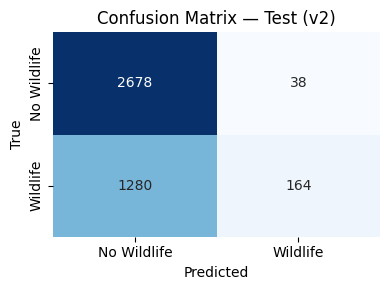

In [3]:
# === Phase 3 (v2): Train & Evaluate RandomForest on new features ===
import os, pandas as pd, numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib, matplotlib.pyplot as plt, seaborn as sns

FEAT_DIR  = "/home/pratyush/Desktop/DS_Project/data/features"
MODEL_DIR = "/home/pratyush/Desktop/DS_Project/models"
RESULTS   = "/home/pratyush/Desktop/DS_Project/results"
SUFFIX    = "v2"
os.makedirs(MODEL_DIR, exist_ok=True); os.makedirs(RESULTS, exist_ok=True)

def load_split(name):
    df = pd.read_csv(os.path.join(FEAT_DIR, f"{name}_hog_color_glcm_{SUFFIX}.csv"))
    X = df.drop(columns=["image","cell_id","label"]).values.astype(np.float32)
    y = df["label"].values.astype(int)
    return X, y

X_train, y_train = load_split("train")
X_val,   y_val   = load_split("val")
X_test,  y_test  = load_split("test")
print("Shapes:", X_train.shape, X_val.shape, X_test.shape)

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight={0:1, 1:2},   # boost recall for wildlife
    n_jobs=-1,
    random_state=42
)
print("\n🚀 Training RF on v2 features...")
rf.fit(X_train, y_train)
joblib.dump(rf, os.path.join(MODEL_DIR, f"rf_hog_color_glcm_{SUFFIX}.pkl"))
print("✅ Model saved.")

# Validation
y_val_pred = rf.predict(X_val)
val_acc = accuracy_score(y_val, y_val_pred)
print(f"\n✅ Validation Accuracy ({SUFFIX}): {val_acc:.4f}")
print(classification_report(y_val, y_val_pred, digits=3))
pd.DataFrame({"true":y_val,"pred":y_val_pred}).to_csv(
    os.path.join(RESULTS, f"val_predictions_{SUFFIX}.csv"), index=False)

# Test
y_test_pred = rf.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)
print(f"\n🧪 Test Accuracy ({SUFFIX}): {test_acc:.4f}")
print(classification_report(y_test, y_test_pred, digits=3))
pd.DataFrame({"true":y_test,"pred":y_test_pred}).to_csv(
    os.path.join(RESULTS, f"test_predictions_{SUFFIX}.csv"), index=False)

# Confusion matrix (test)
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["No Wildlife","Wildlife"],
            yticklabels=["No Wildlife","Wildlife"])
plt.title(f"Confusion Matrix — Test ({SUFFIX})")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout(); plt.show()
